# Matplotlib study

[Matplotlib doc](https://matplotlib.org/stable/index.html)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import librosa
import librosa.display
from sklearn.preprocessing import minmax_scale

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt.cwt2 import cwt2, rd_file, cwt3
from dataprocess.util.data_process import replace_zeroes

from IPython.display import Audio

DATA_DIR = '../data/sound/grasshopper-sound-4/'
CMAP = 'magma'

In [6]:
fn = f'{DATA_DIR}gh-4_mono_denoised_filter.wav'
d1, sr1, dura1 = rd_file(fn)
Audio(d1, rate=sr1)

data type: float32
data size should be 912868.0
size of rd_file data: 912868


In [7]:
F_MAX = sr1 // 2
S = librosa.feature.melspectrogram(y=d1, sr=sr1, n_mels=256, fmax=F_MAX)
S_db = librosa.power_to_db(S, ref=np.max)

d2, sr2 = librosa.load(fn)
d2 = minmax_scale(d2 - d2.mean(), feature_range=(-1,1))
cs1, f1 = cwt3(d2, nv=12, sr=sr2, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')

shape of cs1: (255, 228217)
cs1:
[-8.0580694e-06+1.2683513e-06j  2.1181736e-06-7.1109630e-06j
  5.2300493e-06+1.4626683e-05j -1.9430363e-05-2.2292887e-05j
  3.4956800e-05+3.0435393e-05j -4.7696991e-05-2.7470420e-05j
  4.9424601e-05+1.3650900e-05j -3.4178851e-05+4.4294884e-06j
  6.6717344e-06-2.2490394e-05j  2.2740418e-05+2.7790866e-05j
 -3.8546881e-05-1.7729039e-05j  3.2311269e-05+2.1346325e-06j
 -1.2697736e-05+9.4461266e-06j -4.9249384e-06-6.2910358e-06j
  6.1899304e-06-3.5212199e-06j  4.4029525e-06+4.8543998e-06j
 -7.5066509e-06+4.3371165e-06j -5.0719459e-06-2.1015801e-05j
  2.7976283e-05+3.0992982e-05j -4.5971814e-05-2.8534545e-05j]
shape of f1: (255,)


[<AxesSubplot: > <AxesSubplot: > <AxesSubplot: >]


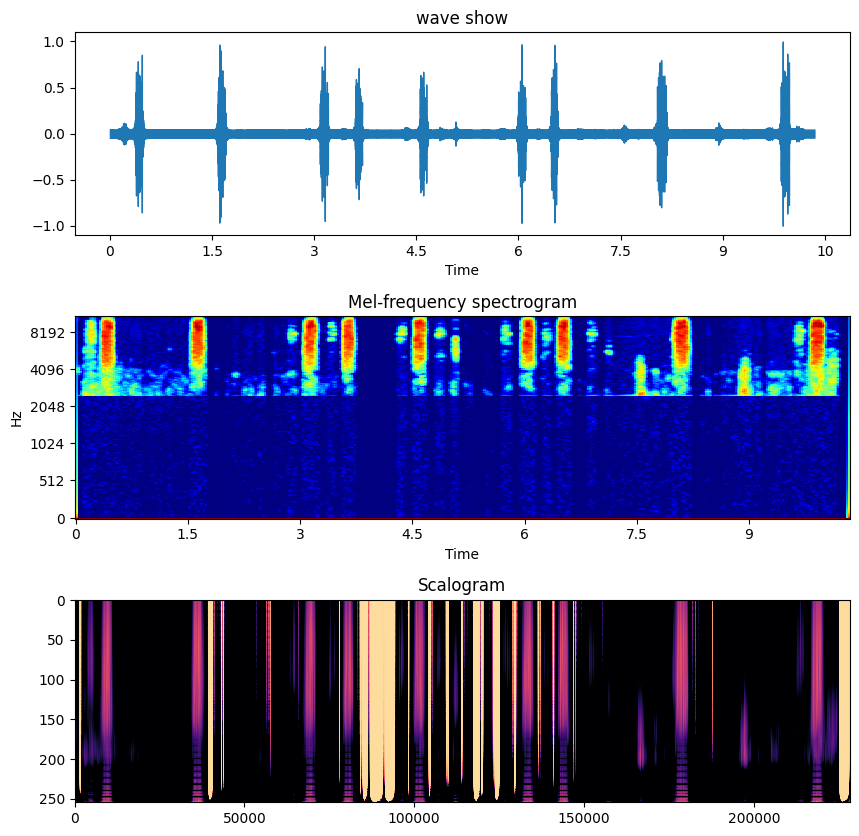

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=False)

librosa.display.waveshow(y=d1, sr=sr1, ax=axes[0])
axes[0].set(title='wave show')

img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr1, fmax=F_MAX, cmap='jet', ax=axes[1])
# fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set(title='Mel-frequency spectrogram')

cs1 = replace_zeroes(cs1)
axes[2].imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-60)
axes[2].set(title='Scalogram')

fig.subplots_adjust(hspace=0.4)
plt.show()


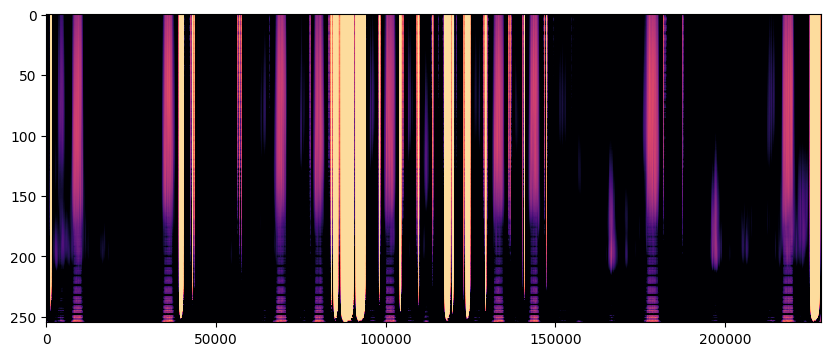

In [18]:
plt.figure(figsize = (10,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap='magma', aspect='auto', norm=None, vmax=0, vmin=-60)
plt.show()